### Data Loading and Preprocessing

Imports

In [1]:
import os
import matplotlib.pyplot as plt 
import math
import seaborn as sns
import pandas as pd
from collections import Counter, defaultdict

Set Path and Load Data

In [2]:
data_path = "data/fr_train.conllu"

with open(data_path, "r", encoding = "utf-8") as f:
    lines = f.readlines()
    
len(lines)

407728

Verify Data

In [3]:
first_twenty = lines[:20]

for l in first_twenty:
    print(l)

# global.columns = ID FORM LEMMA UPOS XPOS FEATS HEAD DEPREL DEPS MISC

# sent_id = fr-ud-train_00001

# text = Les commotions cérébrales sont devenu si courantes dans ce sport qu'on les considére presque comme la routine.

1	Les	le	DET	_	Definite=Def|Number=Plur|PronType=Art	2	det	_	wordform=les

2	commotions	commotion	NOUN	_	Number=Plur	5	nsubj	_	Gender[lex]=Fem

3	cérébrales	cérébral	ADJ	_	Gender=Fem|Number=Plur	2	amod	_	_

4	sont	être	AUX	_	Mood=Ind|Number=Plur|Person=3|Tense=Pres|VerbForm=Fin	5	aux:tense	_	_

5	devenu	devenir	VERB	_	Gender=Masc|Number=Sing|Typo=Yes|VerbForm=Part|Voice=Act	0	root	_	CorrectForm=devenues|CorrectGender=Fem|CorrectNumber=Plur|Tense[denom]=Past

6	si	si	ADV	_	_	7	advmod	_	_

7	courantes	courant	ADJ	_	Gender=Fem|Number=Plur	5	xcomp	_	_

8	dans	dans	ADP	_	_	10	case	_	_

9	ce	ce	DET	_	Gender=Masc|Number=Sing|PronType=Dem	10	det	_	_

10	sport	sport	NOUN	_	Number=Sing	7	obl:mod	_	Gender[lex]=Masc

11	qu'	que	SCONJ	_	_	14	mark	_	SpaceAfter=No

12	on	on	PRON	_

Extract Tokens and POS Tags

In [4]:
tokens = [] # List to store tokens
tags = [] # List to store POS tags
sentences = [] # List to store sentences
tag_sequences = [] # List to store tag sequences for each sentence
current_sentence = [] # Temporary list to build current sentence
current_tags = [] # Temporary list to build current tags

# Iterate through each line in the file
for line in lines:
    line = line.strip() # Remove leading and trailing whitespace
    # Check if line is empty, indicating end of sentence
    if not line:
        # Check if current sentence is not empty
        if current_sentence:
            sentences.append(current_sentence) # Add current sentence to sentence list
            tag_sequences.append(current_tags) # Add current tags to tag list
            current_sentence = [] # Reset current sentence
            current_tags = [] # Reset current tags
        continue
    
    if line.startswith("#"):
        continue # Skip comment lines

    parts = line.split("\t") # Split line into parts using tab as delimiter
    
    if "-" in parts[0]:
        continue # Skip multi-word token lines

    word = parts[1].lower() # Get word and convert to lowercase
    tag = parts[3] # Get UD POS tag
    tokens.append(word) # Add word to tokens list
    tags.append(tag) # Add tag to tags list
    current_sentence.append(word) # Add word to current sentence
    current_tags.append(tag) # Add tag to current tags

len(tokens), len(sentences)

(354648, 14450)

Add Sentence Boundaries

In [5]:
processed_sentences = [["<s>"] + sent + ["</s"] for sent in sentences] # Add start and end tokens to sentences
processed_tags = [["<s>"] + ts + ["/s>"] for ts in tag_sequences] # Add start and end tokens to tag sequences

Flatten Tokens

In [6]:
flat_tokens = [w for s in processed_sentences for w in s] # Flatten sentence list into single token list
flat_tags = [t for ts in processed_tags for t in ts] # Flatten tag list into single tag list

Analyze Vocabulary

In [7]:
vocab = Counter(flat_tokens) # Create vocabulary counter for tokens
tagset = set(flat_tags) # Create set of unique tags

print(f"Vocabulary Size: {len(vocab)}")
print(f"Number of POS Tags: {len(tagset)}")

most_common = vocab.most_common(20) # Get 20 most common tokens

# Iterate through most common tokens and print them with their counts
for w, c in most_common:
    print(f"{w}: {c}")

Vocabulary Size: 39685
Number of POS Tags: 18
de: 23926
,: 16599
<s>: 14450
</s: 14450
le: 13924
.: 13366
la: 9830
à: 9280
les: 8706
et: 7213
l': 6539
en: 5479
est: 4738
d': 4518
un: 3881
une: 3339
il: 3213
dans: 2779
pour: 2241
(: 2211


Visualizations

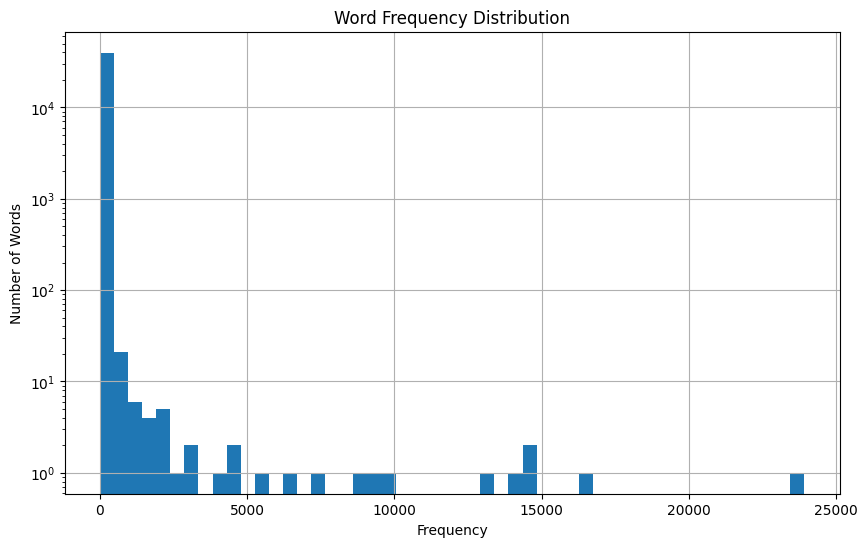

In [8]:
# Word Frequency Histogram
plt.figure(figsize = (10, 6))
plt.hist(vocab.values(), bins = 50, log = True) # Plot histogram of token frequencies with logarithmic scale
plt.title("Word Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Words")
plt.grid(True)
plt.show()


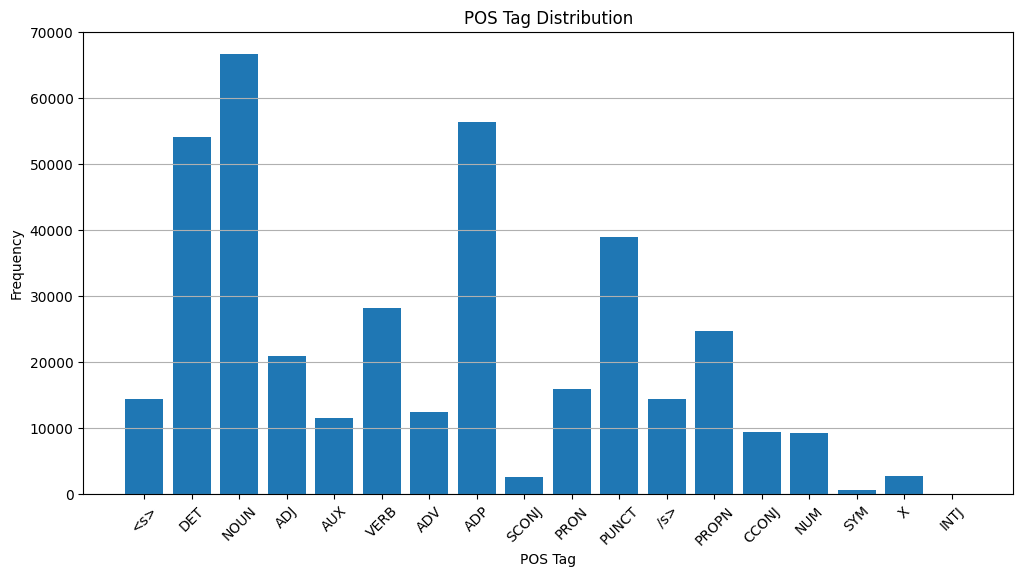

In [9]:
# POS Tag Distribution Bar Chart
tag_counts = Counter(flat_tags) # Count frequency of each POS tag
plt.figure(figsize = (12, 6))
plt.bar(tag_counts.keys(), tag_counts.values()) # Create bar chart of tag frequencies
plt.title("POS Tag Distribution")
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.xticks(rotation = 45) # Rotate x-axis labels for better readability
plt.grid(axis = "y") # Add horizontal grid lines
plt.show()

### Hidden Markov Model POS Tagging

Transition Probabilities

In [10]:
# Count Transitions with Nested Dictionary: P(tag_i | tag_{i-1})
transitions = defaultdict(lambda: defaultdict(int))

# Iterate through tag sequences
for ts in processed_tags:
    # Iterate through tag pairs in the sequence
    for i in range(len(ts) - 1):
        t1, t2 = ts[i], ts[i + 1] # Get current and next tag
        transitions[t1][t2] += 1 # Increment transition count

# Convert counts to probabilities
transition_probs = {} # Dictionary to store transition probabilites

# Iterate through each tag in transitions
for t1 in transitions:
    total = sum(transitions[t1].values()) # Get total transitions from tag t1
    transition_probs[t1] = {t2: count / total for t2, count in transitions[t1].items()} # Normalize counts to probabilities

Visualization

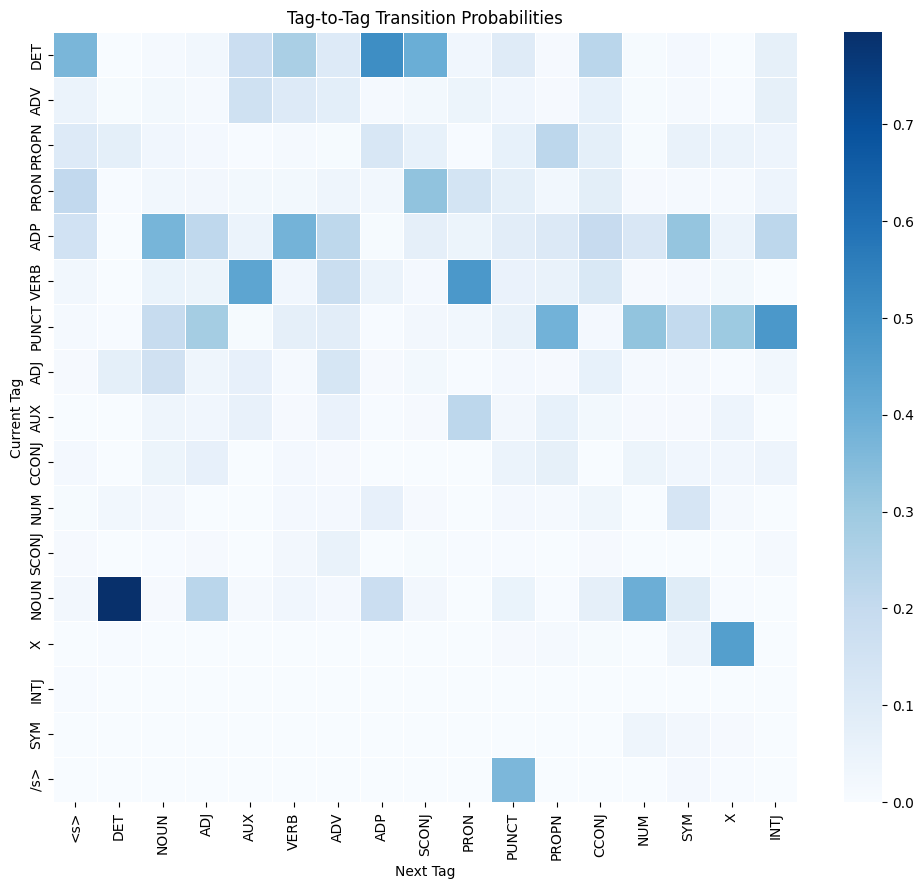

In [11]:
# Heatmap of Tag-to-Tag Transition Probabilities

# Create DataFrame for heatmap
transition_df = pd.DataFrame(transition_probs).fillna(0) # Create DataFrame
plt.figure(figsize = (12, 10))
sns.heatmap(transition_df, cmap = "Blues", linewidths = 0.5) # Plot heatmap of transition probabilities
plt.title("Tag-to-Tag Transition Probabilities")
plt.xlabel("Next Tag")
plt.ylabel("Current Tag")
plt.show()


Emission Probabilites

In [12]:
emissions = defaultdict(lambda: defaultdict(int)) # Nested dictionary to count emissions of words given tags

# Iterate through sentences and their corresponding tag sequences
for sent, ts in zip(processed_sentences, processed_tags):
    # Iterate through words and tags in the sentence
    for w, t in zip(sent, ts):
        emissions[t][w] += 1 # Count emissions of word w given tag t

# Convert counts to probabilities
emission_probs = {} # Dictionary to store emission probabilities

# Iterate through each tag in emissions
for t in emissions:
    total = sum(emissions[t].values()) # Get total emissions for tag t
    emission_probs[t] = {w: count / total for w, count in emissions[t].items()} # Normalize counts to probablilities

In [13]:
# Top Emitted Words Per Common Tag
top_n = 10 # Number of top words to display

# Iterate through most common tags and print top emitted words
for t in ["NOUN", "VERB", "ADJ"]:
    top_emissions = sorted(emission_probs[t].items(), key = lambda x: x[1], reverse = True)[:top_n] # Get top emitted words for tag t
    print(f"Top {top_n} words emitted by tag '{t}':")
    for w, p in top_emissions:
        print(f"{w}: {p:.4f}") # Print word and its emission probability
    print()

Top 10 words emitted by tag 'NOUN':
ans: 0.0046
ville: 0.0039
pays: 0.0038
partie: 0.0036
nom: 0.0036
monde: 0.0035
région: 0.0032
fois: 0.0032
groupe: 0.0031
commune: 0.0031

Top 10 words emitted by tag 'VERB':
a: 0.0116
fait: 0.0103
né: 0.0089
peut: 0.0088
située: 0.0064
faire: 0.0055
situé: 0.0048
partir: 0.0040
trouve: 0.0039
devient: 0.0038

Top 10 words emitted by tag 'ADJ':
premier: 0.0135
première: 0.0132
français: 0.0105
autres: 0.0105
même: 0.0095
française: 0.0084
tous: 0.0080
grande: 0.0073
dernier: 0.0073
grand: 0.0070



Visualization

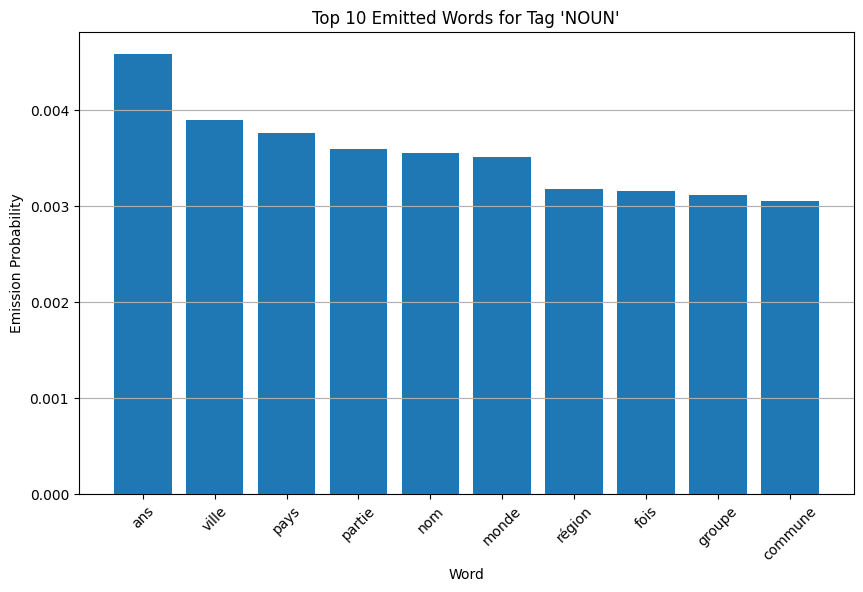

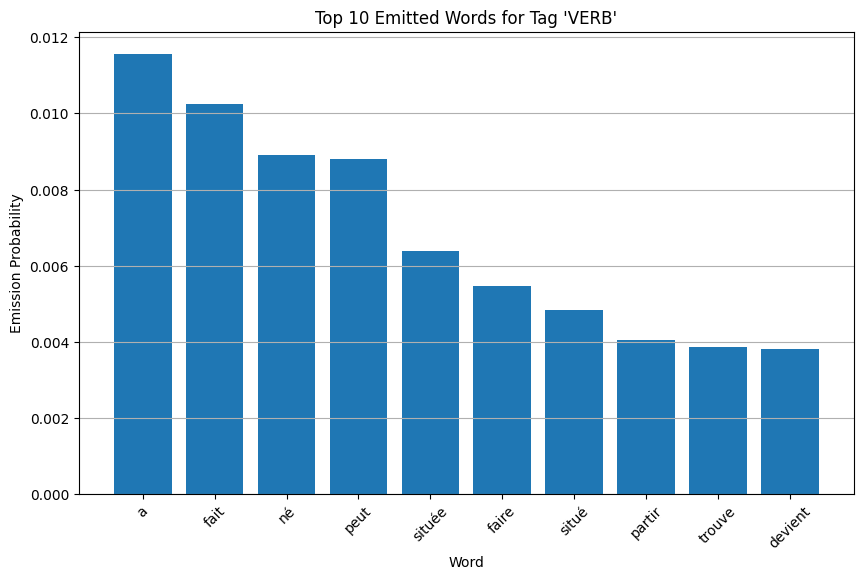

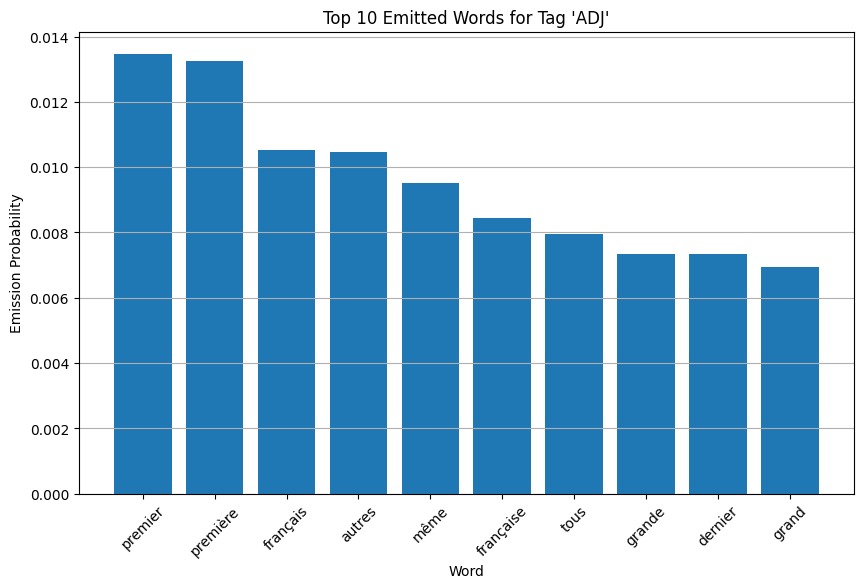

In [14]:
# Bar Chart of Top Emitted Words for Common Tags
top_n = 10 # Number of top words to display

for t in ["NOUN", "VERB", "ADJ"]:
    top_emissions = sorted(emission_probs[t].items(), key = lambda x: x[1], reverse = True)[:top_n] # Get top emitted words for tag t
    words, probs = zip(*top_emissions) # Unzip words and probabilities
    plt.figure(figsize = (10, 6))
    plt.bar(words, probs) # Create bar chart of top emitted words and their probabilities
    plt.title(f"Top {top_n} Emitted Words for Tag '{t}'")
    plt.xlabel("Word")
    plt.ylabel("Emission Probability")
    plt.xticks(rotation = 45) # Rotate x-axis labels for better readability
    plt.grid(axis = "y") # Add horizontal grid lines
    plt.show()

### Viterbi Algorithm for Tagging

Viterbi Implementation

In [19]:
def viterbi(sentence, transition_probs, emission_probs, tagset):
    V = [{}] # Initial Viterbi Matrix
    path = {} # Dictionary to store backpointers for tags

    # Initialize base cases
    # Iterate through each tag in tagset
    for t in tagset:
        # Check if there is transtion from start tag to current tag
        if"<s>" in transition_probs and t in transition_probs["<s>"]:
            # Calculate log probability for initial tag
            V[0][t] = math.log(transition_probs["<s>"].get(t, 1e-8)) + math.log(emission_probs.get(t, {}).get(sentence[0], 1e-8))
            path[t] = [t] # Initialize path for current tag

    # Run Viterbi for t > 0
    for i in range(1, len(sentence)):
        V.append({}) # Add new dictionary for current position
        new_path = {} # Temp dictionary to store new paths for current position
        # Iterate through each tag in tagset for current position
        for tag in tagset:
            # Calculate max probability and best previous tag for current tag
            max_prob, best_prev = max(
                [(V[i-1][prev_tag] + math.log(transition_probs.get(prev_tag, {}).get(tag, 1e-8)) +
                  math.log(emission_probs.get(tag, {}).get(sentence[i], 1e-8)), prev_tag) for prev_tag in V[i-1]],
                  key = lambda x: x[0]
            )
            V[i][tag] = max_prob # Store max probability for current tag
            new_path[tag] = path[best_prev] + [tag] # Update path for current tag
        path = new_path # Update path for next iteration

    # Return best path probability and tags
    n = len(sentence) - 1 # Get index of last word in sentence
    max_prob, best_tag = max((V[n][t], t) for t in tagset) # Get best tag for last word

    return max_prob, path[best_tag], V 

Test Viterbi

In [20]:
sample_sentence = processed_sentences[0][1:-1] # Get first sentence without start and end tokens
prob, predicted_tags, V = viterbi(sample_sentence, transition_probs, emission_probs, tagset) # Run Viterbi algorithm on sample sentence

print(f"Sentence: {sample_sentence}")
print(f"Predicted Tags: {predicted_tags}")
print(f"Log Probability: {prob}")

Sentence: ['les', 'commotions', 'cérébrales', 'sont', 'devenu', 'si', 'courantes', 'dans', 'ce', 'sport', "qu'", 'on', 'les', 'considére', 'presque', 'comme', 'la', 'routine', '.']
Predicted Tags: ['DET', 'NOUN', 'ADJ', 'AUX', 'VERB', 'SCONJ', 'ADJ', 'ADP', 'DET', 'NOUN', 'SCONJ', 'PRON', 'PRON', 'VERB', 'ADV', 'SCONJ', 'DET', 'NOUN', 'PUNCT']
Log Probability: -136.08982519249898


### Evaluation

Tagging Accuracy

In [17]:
correct = 0 # Counter for correct predictions
total = 0 # Counter for total predictions

for sent, gold_tags in zip(processed_sentences, processed_tags):
    words = sent[1:-1] # Get words in sentence without start and end tokens
    gold = gold_tags[1:-1] # Get gold tags without start and end tokens
    _, pred_tags = viterbi(words, transition_probs, emission_probs, tagset) # Get predicted tags using Viterbi algorithm
    # Iterate through gold tags and predicted tags to count correct predictions
    for g, p in zip(gold, pred_tags):
        # If predicted tag mathces gold tag 
        if g == p:
            correct += 1 # Increment correct counter if prediction matches gold tag
            total += 1 # Increment total counter for each prediction

# Calculate and print accuracy of POS tagging
print(f"Accuracy: {correct / total * 100:.2f}%")

Accuracy: 100.00%


Visualization

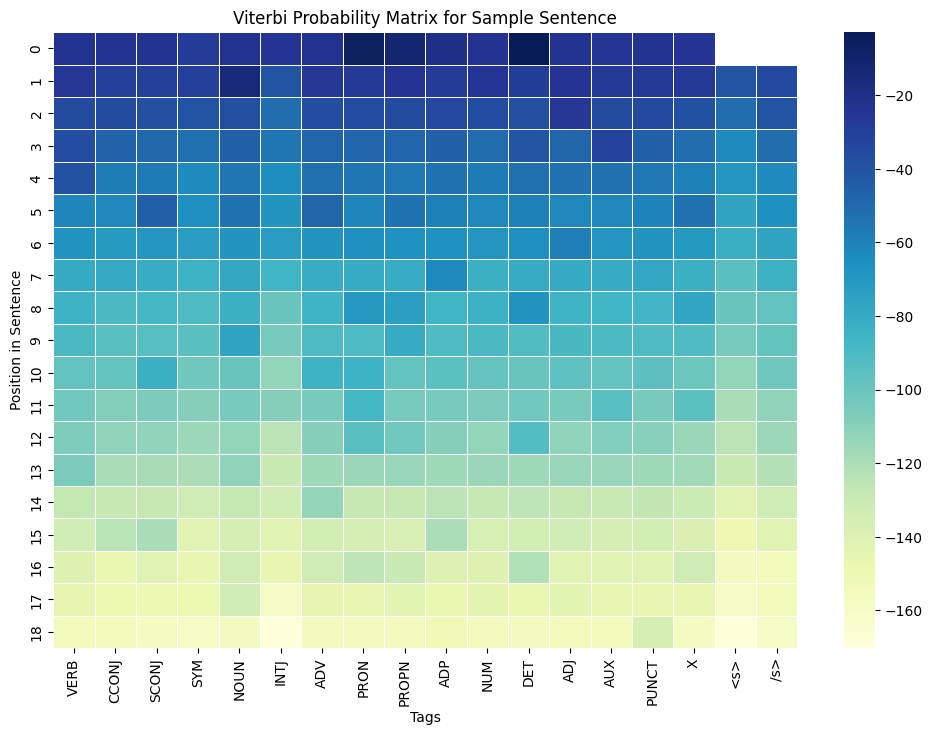

In [21]:
# Viterbi Probability Matrix for Sample Sentence
viterbi_matrix = pd.DataFrame(V) # Create DataFrame from Viterbi matrix

plt.figure(figsize = (12, 8))
sns.heatmap(viterbi_matrix, cmap = "YlGnBu", linewidths = 0.5) # Plot heatmap of Viterbi probabilities
plt.title("Viterbi Probability Matrix for Sample Sentence")
plt.xlabel("Tags")
plt.ylabel("Position in Sentence")
plt.show()